
# Research Engineer Skill Demonstration: LLM Agents, AI Systems, and Evaluation Infrastructure

**Portfolio notebook for a Research Engineer, AI Systems / LLM Agents role.**

This notebook demonstrates the type of hands-on work expected in an AI research engineering role:

- Building simulated LLM-agent research workflows
- Designing reproducible evaluation datasets
- Running benchmark-style experiments
- Measuring pass rate, success rate, hallucination rate, tool error rate, latency, cost, calibration, robustness, and reliability
- Comparing baseline prompting, chain-of-thought-style prompting, ReAct-style agents, tool-using agents, memory-augmented agents, and self-reflective agents
- Visualising results with clear, publication-style figures
- Performing bootstrap confidence intervals, statistical tests, ablation analysis, failure-mode analysis, and Pareto trade-off analysis

## Important note on data provenance

All data in this notebook are **synthetic** and are generated for educational and portfolio demonstration only.  
The simulated values are **calibrated around broad ranges and qualitative benchmark findings** reported in standard LLM-agent and LLM-evaluation literature, including ReAct, HELM, ToolBench/StableToolBench, and SWE-bench. The notebook does **not** claim to reproduce proprietary Meta data or exact leaderboard values.

## Literature anchors used to calibrate the simulation

- ReAct showed that interleaving reasoning and action can improve interactive decision-making performance, including reported absolute success-rate improvements of approximately 34 percentage points on ALFWorld and 10 percentage points on WebShop relative to prior baselines.
- HELM emphasized that language-model evaluation should be multi-metric, not only accuracy-based, and should include calibration, robustness, bias, toxicity, fairness, and efficiency.
- ToolBench and StableToolBench formalized tool-use evaluation using pass-rate and win-rate style metrics, with attention to evaluation stability.
- SWE-bench evaluates whether language models and agents can resolve real software-engineering issues from GitHub repositories.

This notebook uses those ideas to create a realistic research-engineering demonstration.


In [1]:

# ============================================================
# 0. Environment and reproducibility
# ============================================================

import os
import math
import json
import random
import warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from scipy import stats
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report,
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
FIG_DIR = BASE_DIR / "figures"
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print("Environment ready.")
print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Figure directory: {FIG_DIR.resolve()}")


Environment ready.
Data directory: /mnt/data/meta_llm_agent_research_engine_demo/data
Figure directory: /mnt/data/meta_llm_agent_research_engine_demo/figures



## 1. Research question

The imagined research-engineering task is:

> Build and evaluate an internal LLM-agent workflow that can solve mixed research tasks involving retrieval, fact checking, tool calls, code patching, long-horizon planning, and self-correction.

In practice, a Research Engineer would need to:

1. Convert a research hypothesis into an executable experiment.
2. Simulate or curate tasks.
3. Run model/agent variants under controlled settings.
4. Measure success, failure, cost, latency, and reliability.
5. Summarise results for research scientists and engineering partners.


In [2]:

# ============================================================
# 1. Define benchmark-inspired task families and agent variants
# ============================================================

task_families = pd.DataFrame([
    {
        "task_family": "QA_retrieval",
        "literature_anchor": "ReAct / HotpotQA-style retrieval reasoning",
        "description": "Answer multi-hop questions using a retrieval tool.",
        "baseline_success_anchor": 0.50,
        "difficulty": 0.45,
        "expected_tool_need": 0.55,
    },
    {
        "task_family": "fact_verification",
        "literature_anchor": "ReAct / FEVER-style fact checking",
        "description": "Verify a claim using external evidence.",
        "baseline_success_anchor": 0.55,
        "difficulty": 0.42,
        "expected_tool_need": 0.50,
    },
    {
        "task_family": "interactive_web",
        "literature_anchor": "ReAct / WebShop-style interactive decision task",
        "description": "Navigate choices and select the correct item/action.",
        "baseline_success_anchor": 0.35,
        "difficulty": 0.65,
        "expected_tool_need": 0.80,
    },
    {
        "task_family": "embodied_planning",
        "literature_anchor": "ReAct / ALFWorld-style sequential planning",
        "description": "Follow multi-step instructions in a simulated environment.",
        "baseline_success_anchor": 0.22,
        "difficulty": 0.78,
        "expected_tool_need": 0.75,
    },
    {
        "task_family": "tool_api_use",
        "literature_anchor": "ToolBench / StableToolBench-style API use",
        "description": "Choose tools, form valid calls, and combine outputs.",
        "baseline_success_anchor": 0.38,
        "difficulty": 0.70,
        "expected_tool_need": 0.95,
    },
    {
        "task_family": "code_patch",
        "literature_anchor": "SWE-bench-style software issue resolution",
        "description": "Generate a plausible code patch and pass tests.",
        "baseline_success_anchor": 0.18,
        "difficulty": 0.86,
        "expected_tool_need": 0.90,
    },
    {
        "task_family": "safety_policy",
        "literature_anchor": "HELM-style multi-metric evaluation",
        "description": "Answer helpful questions while avoiding unsafe responses.",
        "baseline_success_anchor": 0.72,
        "difficulty": 0.35,
        "expected_tool_need": 0.20,
    },
])

agent_variants = pd.DataFrame([
    {
        "agent": "Direct_LLM",
        "short_name": "Direct",
        "design": "Single prompt, no explicit reasoning/action loop.",
        "skill_bonus": 0.00,
        "tool_bonus": -0.04,
        "latency_multiplier": 1.00,
        "cost_multiplier": 1.00,
        "hallucination_modifier": 1.00,
    },
    {
        "agent": "CoT_prompted",
        "short_name": "CoT",
        "design": "Reasoning prompt, no real environment action.",
        "skill_bonus": 0.05,
        "tool_bonus": -0.02,
        "latency_multiplier": 1.25,
        "cost_multiplier": 1.20,
        "hallucination_modifier": 0.92,
    },
    {
        "agent": "ReAct_agent",
        "short_name": "ReAct",
        "design": "Interleaves reasoning and tool/environment actions.",
        "skill_bonus": 0.10,
        "tool_bonus": 0.13,
        "latency_multiplier": 1.75,
        "cost_multiplier": 1.65,
        "hallucination_modifier": 0.72,
    },
    {
        "agent": "Tool_router_agent",
        "short_name": "Tool-router",
        "design": "Adds structured tool selection and schema validation.",
        "skill_bonus": 0.12,
        "tool_bonus": 0.18,
        "latency_multiplier": 1.90,
        "cost_multiplier": 1.75,
        "hallucination_modifier": 0.68,
    },
    {
        "agent": "Memory_agent",
        "short_name": "Memory",
        "design": "Adds retrieval memory of previous solved trajectories.",
        "skill_bonus": 0.15,
        "tool_bonus": 0.16,
        "latency_multiplier": 2.10,
        "cost_multiplier": 1.95,
        "hallucination_modifier": 0.65,
    },
    {
        "agent": "Self_reflecting_agent",
        "short_name": "Reflect",
        "design": "Adds critique-and-retry after failed intermediate checks.",
        "skill_bonus": 0.18,
        "tool_bonus": 0.20,
        "latency_multiplier": 2.45,
        "cost_multiplier": 2.35,
        "hallucination_modifier": 0.58,
    },
])

task_families, agent_variants


(         task_family  ... expected_tool_need
 0       QA_retrieval  ...               0.55
 1  fact_verification  ...               0.50
 2    interactive_web  ...               0.80
 3  embodied_planning  ...               0.75
 4       tool_api_use  ...               0.95
 5         code_patch  ...               0.90
 6      safety_policy  ...               0.20
 
 [7 rows x 6 columns],
                    agent   short_name  ... cost_multiplier  hallucination_modifier
 0             Direct_LLM       Direct  ...            1.00                    1.00
 1           CoT_prompted          CoT  ...            1.20                    0.92
 2            ReAct_agent        ReAct  ...            1.65                    0.72
 3      Tool_router_agent  Tool-router  ...            1.75                    0.68
 4           Memory_agent       Memory  ...            1.95                    0.65
 5  Self_reflecting_agent      Reflect  ...            2.35                    0.58
 
 [6 rows x 8 colu


## 2. Synthetic experiment generator

The simulation below generates individual task runs. Each row is one attempted task by one agent variant.

The simulation captures realistic engineering concerns:

- Some tasks are harder than others.
- Tool-heavy tasks penalise direct prompting and reward structured tool use.
- Long tasks increase latency, cost, and failure probability.
- More capable agents can still fail by hallucination, invalid tool calls, timeout, or wrong final answer.
- Predicted confidence is imperfectly calibrated, so calibration can be measured.


In [3]:

# ============================================================
# 2. Generate benchmark-inspired synthetic evaluation data
# ============================================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def logit(p):
    p = np.clip(p, 1e-5, 1 - 1e-5)
    return np.log(p / (1 - p))

n_tasks_per_family = 120
replicates_per_agent = 1

rows = []
task_id = 0

for _, t in task_families.iterrows():
    for i in range(n_tasks_per_family):
        task_id += 1

        # Task-level random effects
        task_complexity = np.clip(rng.normal(t["difficulty"], 0.14), 0.05, 0.98)
        tool_need = np.clip(rng.normal(t["expected_tool_need"], 0.12), 0.00, 1.00)
        ambiguity = np.clip(rng.beta(2.2, 5.0) + 0.2 * task_complexity, 0, 1)
        context_length_k = np.clip(rng.gamma(shape=3.2, scale=2.2), 0.5, 32)

        for _, a in agent_variants.iterrows():
            # Base success is anchored to task family, adjusted by agent capability and tool need.
            base = logit(t["baseline_success_anchor"])
            agent_effect = a["skill_bonus"] * 2.4 + a["tool_bonus"] * 2.0 * tool_need
            difficulty_penalty = -1.55 * task_complexity
            ambiguity_penalty = -0.65 * ambiguity
            context_penalty = -0.018 * context_length_k
            random_noise = rng.normal(0, 0.16)

            success_prob = sigmoid(base + agent_effect + difficulty_penalty + ambiguity_penalty + context_penalty + random_noise)
            success = rng.binomial(1, success_prob)

            # Tool error probability is high for tool-heavy tasks, lower with stronger tool routers.
            tool_maturity = max(a["tool_bonus"], -0.04)
            tool_error_prob = np.clip(0.05 + 0.32 * tool_need + 0.14 * task_complexity - 0.75 * tool_maturity, 0.01, 0.65)
            invalid_tool_call = rng.binomial(1, tool_error_prob)

            # Hallucination risk: reduced by ReAct/tool/memory/reflection, increased by ambiguity and failure.
            hallucination_prob = np.clip(
                (0.10 + 0.22 * ambiguity + 0.12 * task_complexity + 0.10 * (1 - success))
                * a["hallucination_modifier"],
                0.01, 0.70
            )
            hallucination = rng.binomial(1, hallucination_prob)

            # Timeout risk increases for complex, long-context, tool-heavy tasks.
            timeout_prob = np.clip(0.015 + 0.08 * task_complexity + 0.025 * context_length_k / 10 + 0.05 * tool_need, 0.005, 0.35)
            timeout = rng.binomial(1, timeout_prob)

            # Latency and token/cost model.
            base_latency = 4.5 + 22 * task_complexity + 0.85 * context_length_k + 10 * tool_need
            latency_sec = np.clip(rng.lognormal(np.log(base_latency * a["latency_multiplier"]), 0.25), 1, 420)

            input_tokens = int(np.clip(rng.normal(700 + 310 * context_length_k, 180), 150, 12000))
            output_tokens = int(np.clip(rng.normal(380 + 800 * a["latency_multiplier"] + 600 * task_complexity, 220), 80, 6500))
            total_tokens = input_tokens + output_tokens

            # Synthetic cost in arbitrary research-accounting units, not dollars.
            cost_units = (total_tokens / 1000.0) * 0.012 * a["cost_multiplier"]

            # Confidence is partially calibrated but overconfident on hallucinations and timeouts.
            confidence = np.clip(
                success_prob + rng.normal(0, 0.12) + 0.08 * (a["skill_bonus"] > 0.1) - 0.08 * hallucination,
                0.02,
                0.99
            )

            # Failure label prioritises actionable engineering categories.
            if success:
                failure_mode = "success"
            elif timeout:
                failure_mode = "timeout"
            elif invalid_tool_call:
                failure_mode = "invalid_tool_call"
            elif hallucination:
                failure_mode = "hallucination"
            elif ambiguity > 0.55:
                failure_mode = "ambiguous_instruction"
            else:
                failure_mode = "wrong_final_answer"

            # Robustness stress: noisy prompt, tool delay, evidence conflict, or schema perturbation.
            stress_type = rng.choice(["none", "prompt_noise", "tool_delay", "schema_shift", "evidence_conflict"], 
                                     p=[0.45, 0.18, 0.14, 0.12, 0.11])
            stress_penalty = {
                "none": 0.00,
                "prompt_noise": 0.04,
                "tool_delay": 0.06,
                "schema_shift": 0.09,
                "evidence_conflict": 0.11,
            }[stress_type]
            stressed_success_prob = np.clip(success_prob - stress_penalty - 0.03 * tool_need, 0.01, 0.99)
            stressed_success = rng.binomial(1, stressed_success_prob)

            rows.append({
                "task_id": f"T{task_id:04d}",
                "task_family": t["task_family"],
                "literature_anchor": t["literature_anchor"],
                "agent": a["agent"],
                "agent_short": a["short_name"],
                "task_complexity": task_complexity,
                "tool_need": tool_need,
                "ambiguity": ambiguity,
                "context_length_k": context_length_k,
                "success_prob_true": success_prob,
                "success": success,
                "pass_at_1": success,
                "confidence": confidence,
                "invalid_tool_call": invalid_tool_call,
                "hallucination": hallucination,
                "timeout": timeout,
                "latency_sec": latency_sec,
                "input_tokens": input_tokens,
                "output_tokens": output_tokens,
                "total_tokens": total_tokens,
                "cost_units": cost_units,
                "failure_mode": failure_mode,
                "stress_type": stress_type,
                "stressed_success": stressed_success,
            })

df = pd.DataFrame(rows)

# Save synthetic dataset
df.to_csv(DATA_DIR / "synthetic_llm_agent_runs.csv", index=False)
task_families.to_csv(DATA_DIR / "task_family_metadata.csv", index=False)
agent_variants.to_csv(DATA_DIR / "agent_variant_metadata.csv", index=False)

print(df.shape)
df.head()


(5040, 24)


,task_id,task_family,literature_anchor,agent,agent_short,task_complexity,tool_need,ambiguity,context_length_k,success_prob_true,success,pass_at_1,confidence,invalid_tool_call,hallucination,timeout,latency_sec,input_tokens,output_tokens,total_tokens,cost_units,failure_mode,stress_type,stressed_success
0,T0001,QA_retrieval,ReAct / HotpotQA-style retrieval reasoning,Direct_LLM,Direct,0.49266,0.425202,0.48303,6.244291,0.252882,1,1,0.278296,0,1,0,20.084979,2702,1264,3966,0.047592,success,tool_delay,0
1,T0001,QA_retrieval,ReAct / HotpotQA-style retrieval reasoning,CoT_prompted,CoT,0.49266,0.425202,0.48303,6.244291,0.232197,1,1,0.203896,1,1,0,35.552702,2701,1766,4467,0.064325,success,tool_delay,1
2,T0001,QA_retrieval,ReAct / HotpotQA-style retrieval reasoning,ReAct_agent,ReAct,0.49266,0.425202,0.48303,6.244291,0.284673,0,0,0.373864,0,0,0,35.317267,2487,2218,4705,0.093159,wrong_final_answer,schema_shift,0
3,T0001,QA_retrieval,ReAct / HotpotQA-style retrieval reasoning,Tool_router_agent,Tool-router,0.49266,0.425202,0.48303,6.244291,0.340288,1,1,0.428397,0,0,0,58.821439,2675,2344,5019,0.105399,success,schema_shift,0
4,T0001,QA_retrieval,ReAct / HotpotQA-style retrieval reasoning,Memory_agent,Memory,0.49266,0.425202,0.48303,6.244291,0.283519,1,1,0.161575,0,0,0,75.979836,2479,2568,5047,0.118100,success,tool_delay,0


In [4]:

# ============================================================
# 3. Core aggregate metrics
# ============================================================

def ece_score(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if np.sum(mask) == 0:
            continue
        acc = np.mean(y_true[mask])
        conf = np.mean(y_prob[mask])
        ece += np.sum(mask) / len(y_true) * abs(acc - conf)
    return ece

summary = (
    df.groupby("agent_short")
    .agg(
        n=("success", "size"),
        success_rate=("success", "mean"),
        hallucination_rate=("hallucination", "mean"),
        invalid_tool_rate=("invalid_tool_call", "mean"),
        timeout_rate=("timeout", "mean"),
        stressed_success_rate=("stressed_success", "mean"),
        mean_latency_sec=("latency_sec", "mean"),
        median_latency_sec=("latency_sec", "median"),
        mean_cost_units=("cost_units", "mean"),
        mean_tokens=("total_tokens", "mean"),
        mean_confidence=("confidence", "mean"),
    )
    .reset_index()
)

calibration = []
for agent, sub in df.groupby("agent_short"):
    calibration.append({
        "agent_short": agent,
        "brier": brier_score_loss(sub["success"], sub["confidence"]),
        "ece": ece_score(sub["success"].values, sub["confidence"].values, n_bins=10),
        "robustness_drop": sub["success"].mean() - sub["stressed_success"].mean(),
    })
calibration = pd.DataFrame(calibration)

summary = summary.merge(calibration, on="agent_short")
summary = summary.sort_values("success_rate", ascending=False)
summary.to_csv(DATA_DIR / "agent_summary_metrics.csv", index=False)

summary


,agent_short,n,success_rate,hallucination_rate,invalid_tool_rate,timeout_rate,stressed_success_rate,mean_latency_sec,median_latency_sec,mean_cost_units,mean_tokens,mean_confidence,brier,ece,robustness_drop
4,Reflect,840,0.301190,0.203571,0.186905,0.108333,0.248810,75.822678,73.141009,0.154881,5492.238095,0.369472,0.190519,0.083231,0.052381
5,Tool-router,840,0.272619,0.215476,0.223810,0.107143,0.238095,58.452291,56.453479,0.106499,5071.384524,0.334048,0.175391,0.073598,0.034524
3,ReAct,840,0.257143,0.264286,0.247619,0.122619,0.227381,54.771697,52.061084,0.097362,4917.294048,0.244174,0.166304,0.036730,0.029762
2,Memory,840,0.254762,0.210714,0.255952,0.091667,0.201190,64.755320,63.254092,0.122011,5214.163095,0.346963,0.176360,0.097113,0.053571
0,CoT,840,0.203571,0.321429,0.380952,0.130952,0.171429,39.623759,37.367483,0.065279,4533.238095,0.203609,0.141291,0.036892,0.032143
1,Direct,840,0.189286,0.341667,0.402381,0.101190,0.158333,31.139889,29.675434,0.051770,4314.175000,0.190399,0.138908,0.056149,0.030952



## 3. Benchmark-style results

The next plots show how different agent designs trade off capability, latency, cost, and reliability.

A strong research engineer should not only report “best accuracy”; they should expose the full engineering trade space.


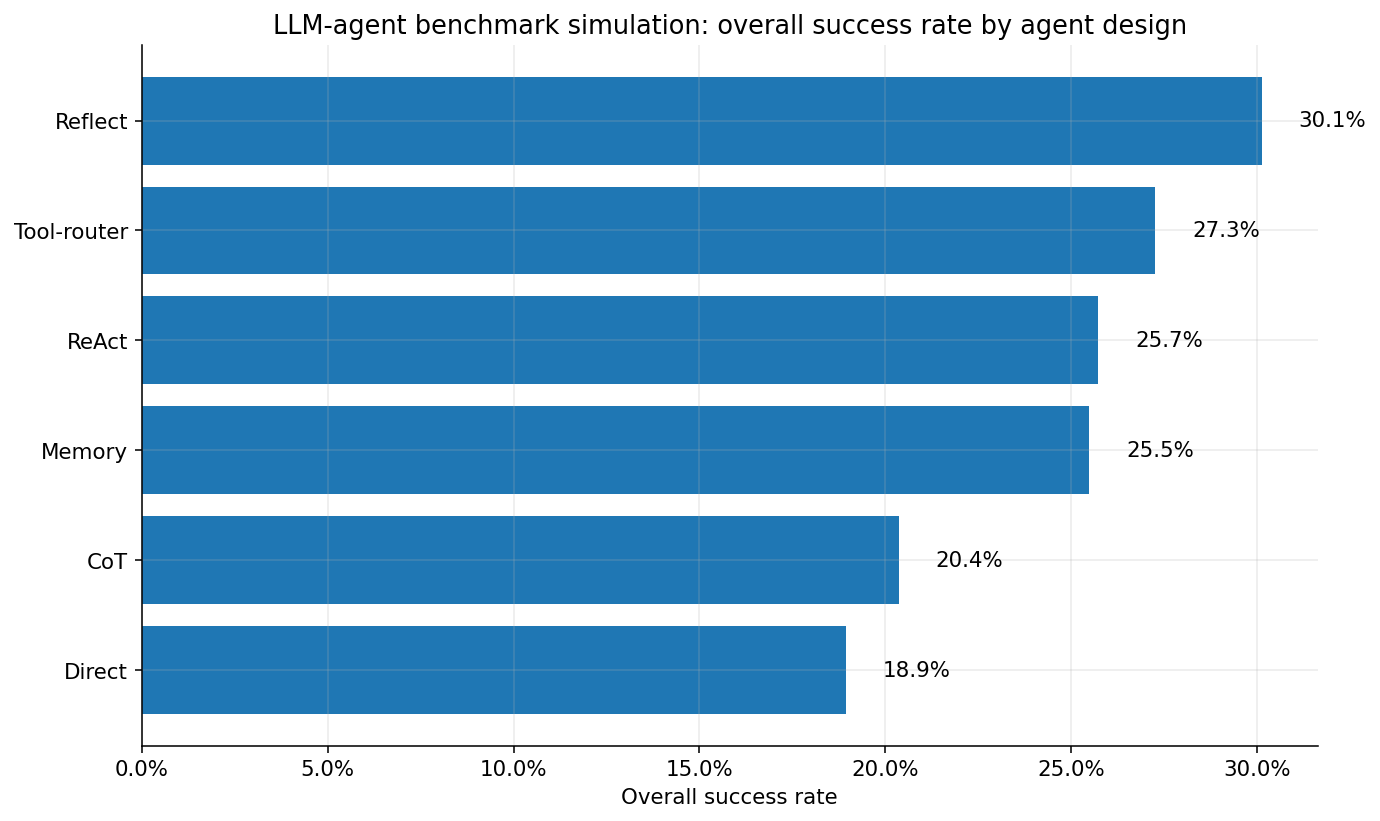

In [5]:

# ============================================================
# 4. Visual 1: Agent performance dashboard
# ============================================================

order = summary.sort_values("success_rate", ascending=True)["agent_short"].tolist()

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(order))
vals = summary.set_index("agent_short").loc[order, "success_rate"]
ax.barh(y, vals)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Overall success rate")
ax.set_title("LLM-agent benchmark simulation: overall success rate by agent design")
for i, v in enumerate(vals):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_overall_success_rate.png", bbox_inches="tight")
plt.show()


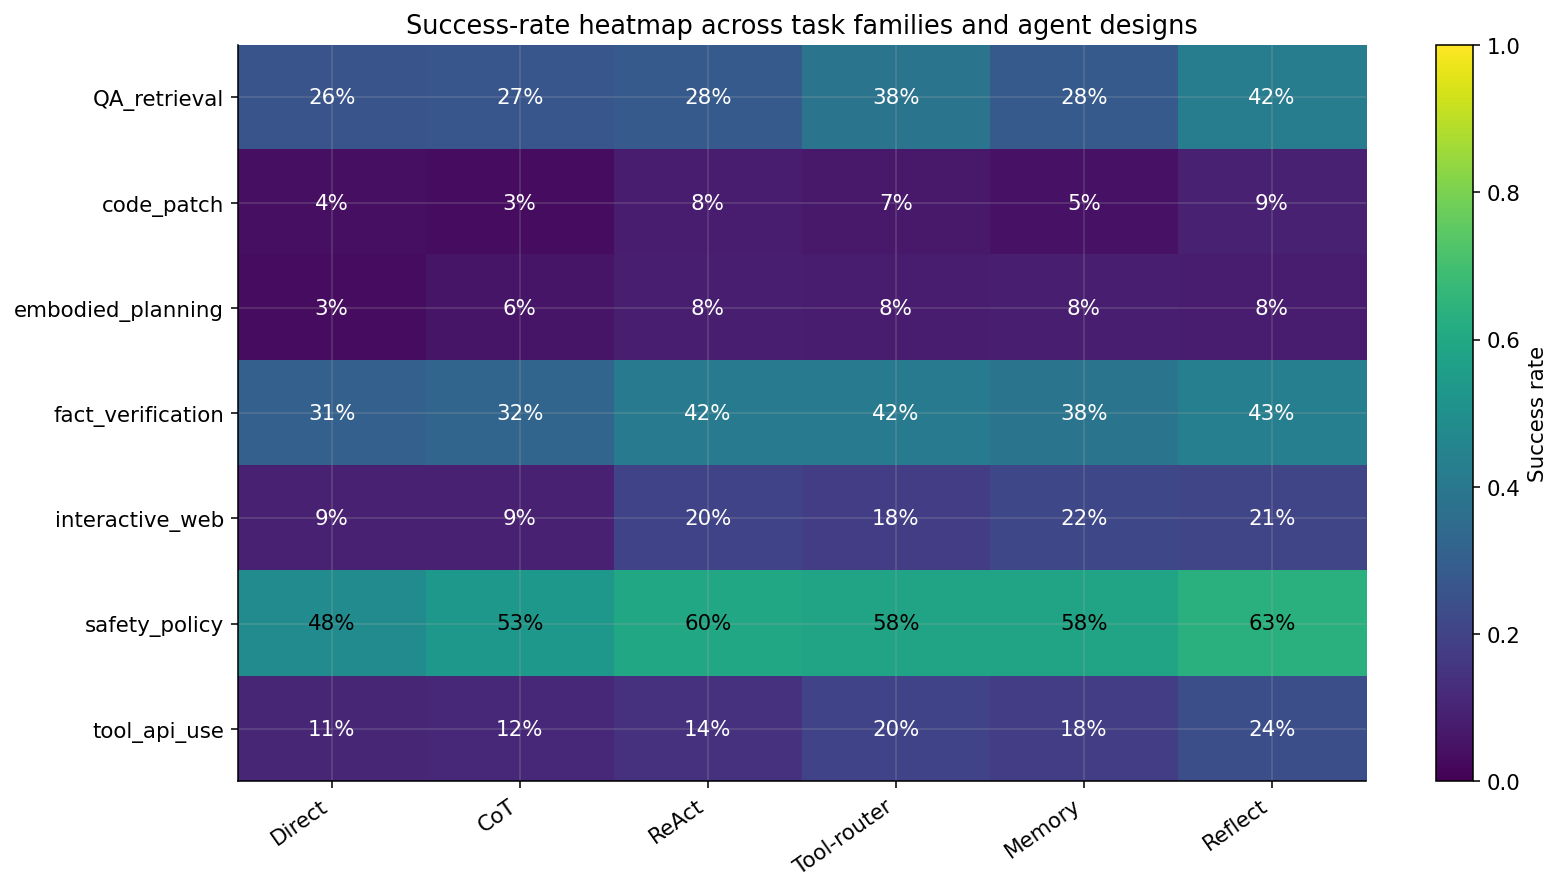

agent_short,Direct,CoT,ReAct,Tool-router,Memory,Reflect
task_family,,,,,,
QA_retrieval,0.258333,0.266667,0.283333,0.383333,0.283333,0.425000
code_patch,0.041667,0.033333,0.075000,0.066667,0.050000,0.091667
embodied_planning,0.033333,0.058333,0.083333,0.075000,0.083333,0.075000
fact_verification,0.308333,0.325000,0.416667,0.416667,0.383333,0.433333
interactive_web,0.091667,0.091667,0.200000,0.183333,0.216667,0.208333
safety_policy,0.483333,0.533333,0.600000,0.583333,0.583333,0.633333
tool_api_use,0.108333,0.116667,0.141667,0.200000,0.183333,0.241667


In [6]:

# ============================================================
# 5. Visual 2: Task x agent heatmap
# ============================================================

heat = df.pivot_table(index="task_family", columns="agent_short", values="success", aggfunc="mean")
heat = heat[["Direct", "CoT", "ReAct", "Tool-router", "Memory", "Reflect"]]

fig, ax = plt.subplots(figsize=(12, 6.5))
im = ax.imshow(heat.values, aspect="auto", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title("Success-rate heatmap across task families and agent designs")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Success rate")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.iloc[i, j]:.0%}", ha="center", va="center", color="white" if heat.iloc[i,j] < 0.45 else "black")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_task_agent_heatmap.png", bbox_inches="tight")
plt.show()

heat


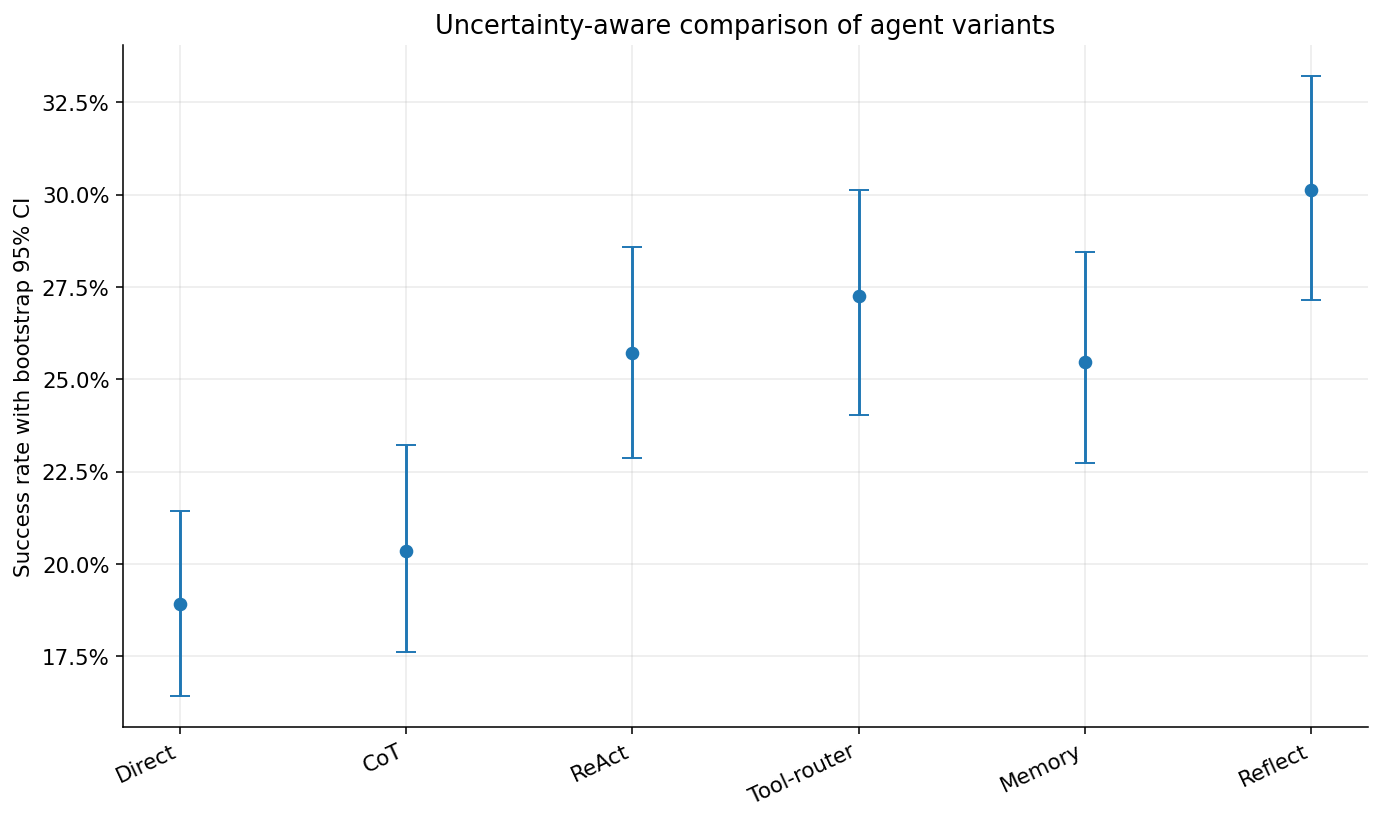

,agent_short,success_rate,ci_low,ci_high
1,Direct,0.189286,0.164286,0.214315
0,CoT,0.203571,0.176190,0.232143
3,ReAct,0.257143,0.228571,0.285714
5,Tool-router,0.272619,0.240476,0.301190
2,Memory,0.254762,0.227351,0.284524
4,Reflect,0.301190,0.271429,0.332143


In [7]:

# ============================================================
# 6. Bootstrap confidence intervals
# ============================================================

def bootstrap_ci(values, n_boot=2000, alpha=0.05):
    values = np.asarray(values)
    boots = []
    for _ in range(n_boot):
        boots.append(np.mean(rng.choice(values, size=len(values), replace=True)))
    return np.quantile(boots, [alpha/2, 1-alpha/2])

ci_rows = []
for agent, sub in df.groupby("agent_short"):
    low, high = bootstrap_ci(sub["success"].values)
    ci_rows.append({
        "agent_short": agent,
        "success_rate": sub["success"].mean(),
        "ci_low": low,
        "ci_high": high,
    })
ci = pd.DataFrame(ci_rows)
ci["agent_short"] = pd.Categorical(ci["agent_short"], categories=["Direct","CoT","ReAct","Tool-router","Memory","Reflect"], ordered=True)
ci = ci.sort_values("agent_short")
ci.to_csv(DATA_DIR / "bootstrap_success_ci.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(ci))
ax.errorbar(
    x,
    ci["success_rate"],
    yerr=[ci["success_rate"] - ci["ci_low"], ci["ci_high"] - ci["success_rate"]],
    fmt="o",
    capsize=5,
)
ax.set_xticks(x)
ax.set_xticklabels(ci["agent_short"], rotation=25, ha="right")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel("Success rate with bootstrap 95% CI")
ax.set_title("Uncertainty-aware comparison of agent variants")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_bootstrap_ci.png", bbox_inches="tight")
plt.show()

ci


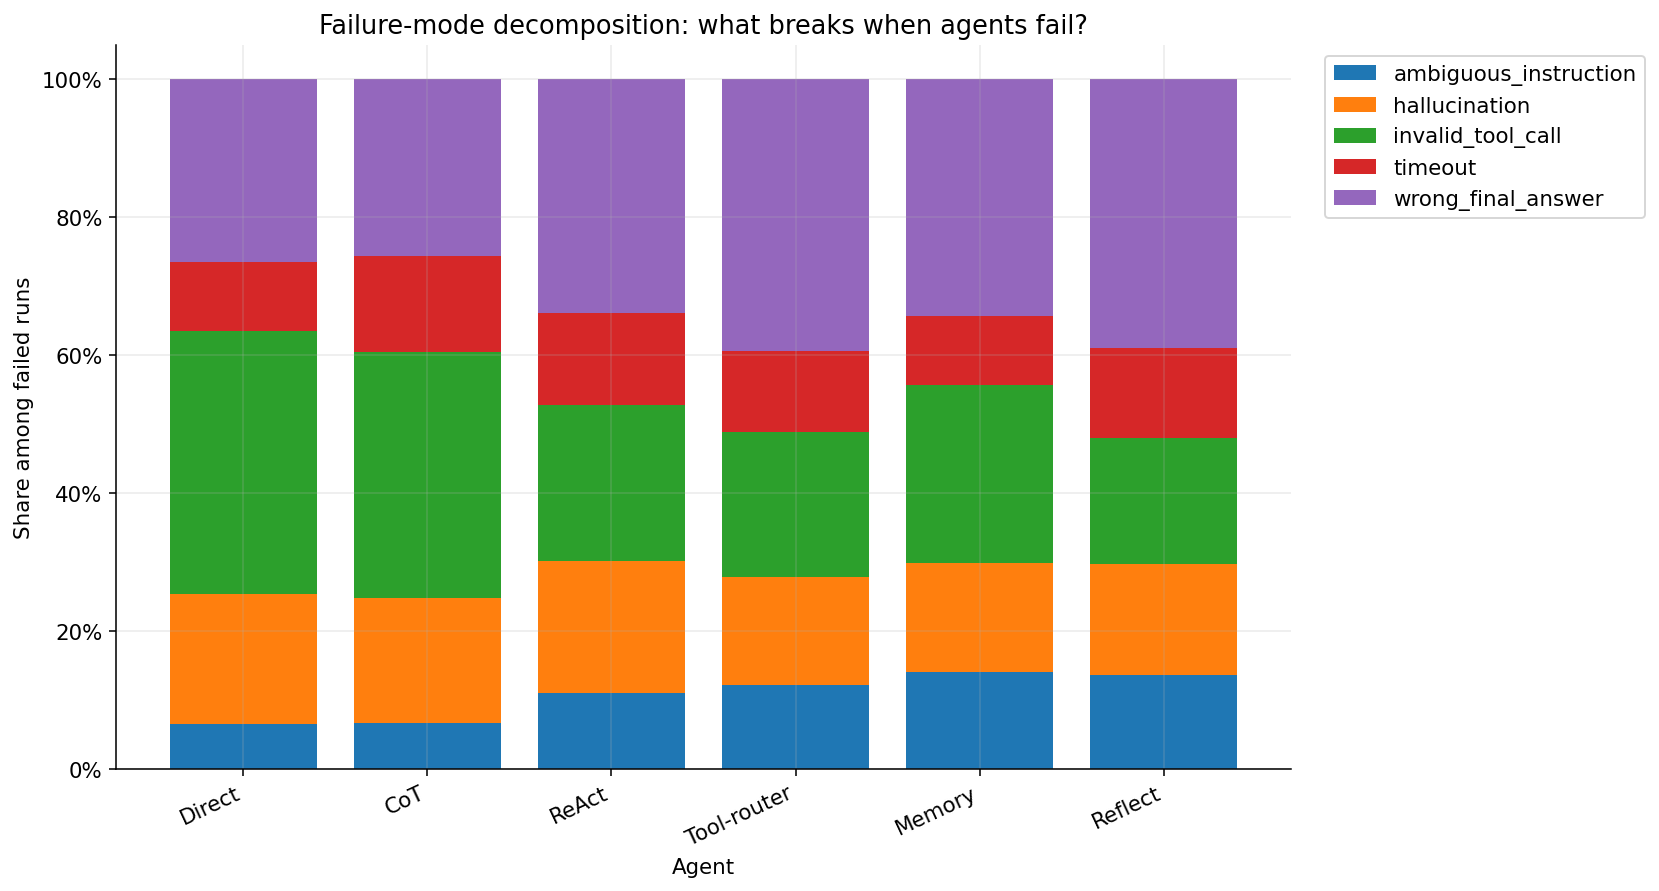

failure_mode,ambiguous_instruction,hallucination,invalid_tool_call,timeout,wrong_final_answer
agent_short,,,,,
Direct,0.066079,0.187959,0.381791,0.099853,0.264317
CoT,0.067265,0.180867,0.357250,0.139013,0.255605
ReAct,0.110577,0.190705,0.225962,0.134615,0.338141
Tool-router,0.122750,0.155483,0.211129,0.116203,0.394435
Memory,0.140575,0.158147,0.258786,0.099042,0.343450
Reflect,0.136286,0.161840,0.182283,0.129472,0.390119


In [8]:

# ============================================================
# 7. Visual 4: Failure modes
# ============================================================

fail = (
    df[df["failure_mode"] != "success"]
    .groupby(["agent_short", "failure_mode"])
    .size()
    .reset_index(name="count")
)
fail["share_within_agent_failures"] = fail.groupby("agent_short")["count"].transform(lambda x: x / x.sum())

fail_pivot = fail.pivot(index="agent_short", columns="failure_mode", values="share_within_agent_failures").fillna(0)
fail_pivot = fail_pivot.loc[["Direct","CoT","ReAct","Tool-router","Memory","Reflect"]]

fig, ax = plt.subplots(figsize=(12, 6.5))
bottom = np.zeros(len(fail_pivot))
for col in fail_pivot.columns:
    ax.bar(fail_pivot.index, fail_pivot[col], bottom=bottom, label=col)
    bottom += fail_pivot[col].values

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel("Share among failed runs")
ax.set_xlabel("Agent")
ax.set_title("Failure-mode decomposition: what breaks when agents fail?")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_failure_modes.png", bbox_inches="tight")
plt.show()

fail_pivot


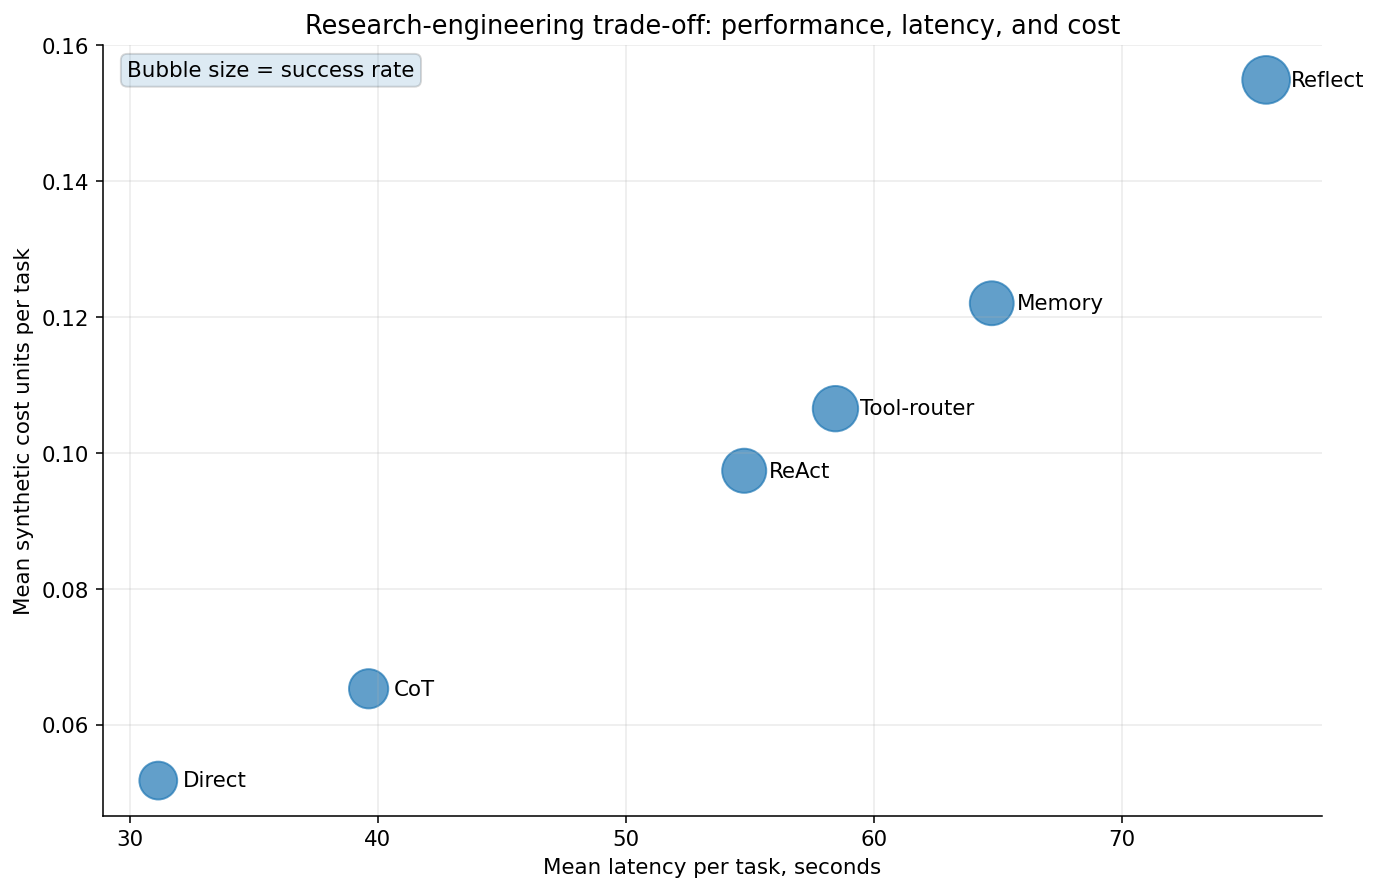

In [9]:

# ============================================================
# 8. Visual 5: Cost-latency-performance trade-off
# ============================================================

plot_df = summary.copy()
fig, ax = plt.subplots(figsize=(10, 6.5))

sizes = 2000 * plot_df["success_rate"]
ax.scatter(
    plot_df["mean_latency_sec"],
    plot_df["mean_cost_units"],
    s=sizes,
    alpha=0.70,
)

for _, row in plot_df.iterrows():
    ax.text(row["mean_latency_sec"] + 1, row["mean_cost_units"], row["agent_short"], va="center")

ax.set_xlabel("Mean latency per task, seconds")
ax.set_ylabel("Mean synthetic cost units per task")
ax.set_title("Research-engineering trade-off: performance, latency, and cost")
ax.text(
    0.02, 0.98,
    "Bubble size = success rate",
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_cost_latency_tradeoff.png", bbox_inches="tight")
plt.show()


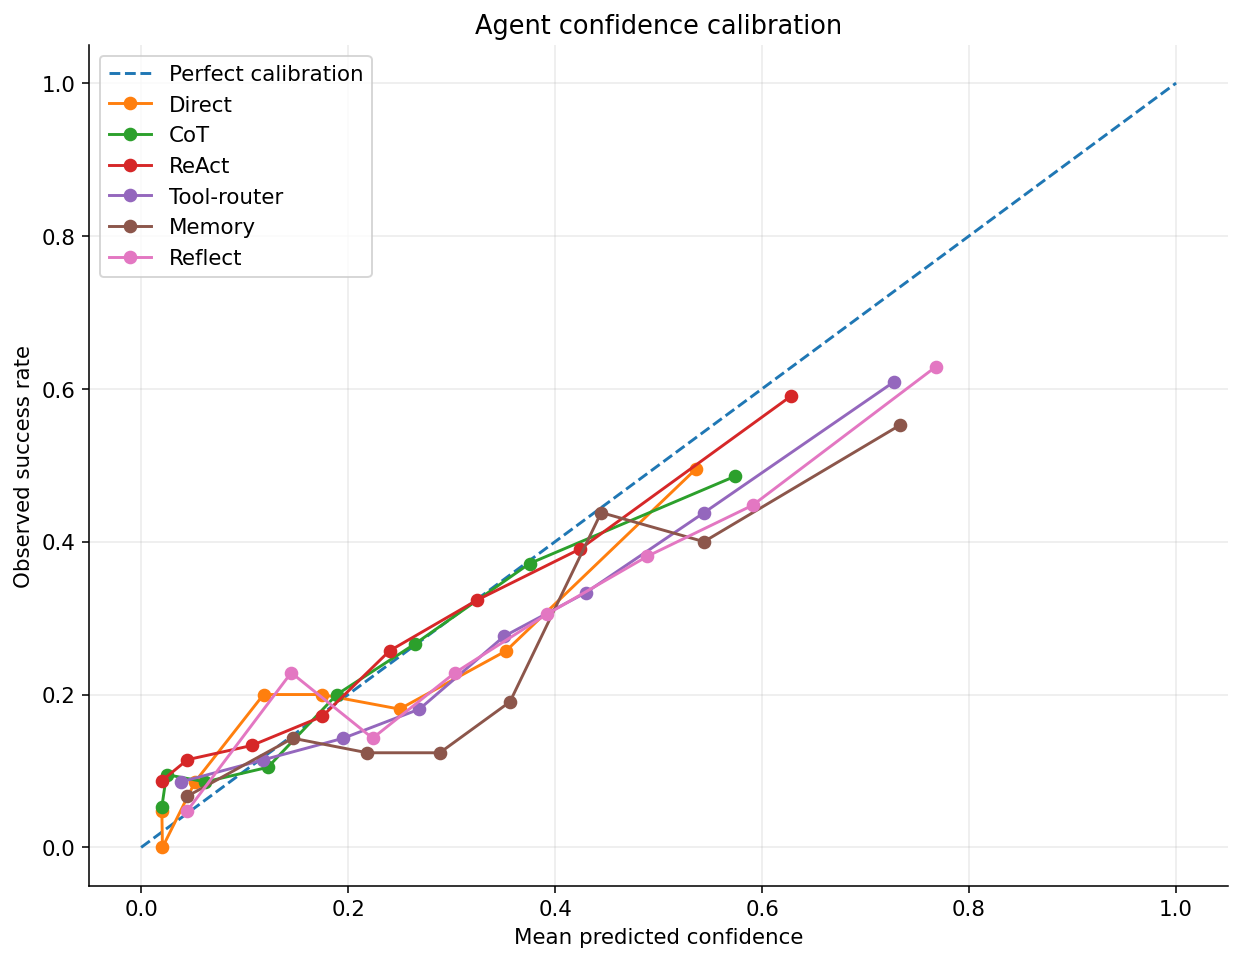

,agent_short,brier,ece,mean_confidence,success_rate
3,ReAct,0.166304,0.036730,0.244174,0.257143
0,CoT,0.141291,0.036892,0.203609,0.203571
1,Direct,0.138908,0.056149,0.190399,0.189286
5,Tool-router,0.175391,0.073598,0.334048,0.272619
4,Reflect,0.190519,0.083231,0.369472,0.301190
2,Memory,0.176360,0.097113,0.346963,0.254762


In [10]:

# ============================================================
# 9. Visual 6: Calibration curves
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

for agent in ["Direct","CoT","ReAct","Tool-router","Memory","Reflect"]:
    sub = df[df["agent_short"] == agent]
    prob_true, prob_pred = calibration_curve(sub["success"], sub["confidence"], n_bins=8, strategy="quantile")
    ax.plot(prob_pred, prob_true, marker="o", label=agent)

ax.set_xlabel("Mean predicted confidence")
ax.set_ylabel("Observed success rate")
ax.set_title("Agent confidence calibration")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "06_calibration_curves.png", bbox_inches="tight")
plt.show()

summary[["agent_short", "brier", "ece", "mean_confidence", "success_rate"]].sort_values("ece")


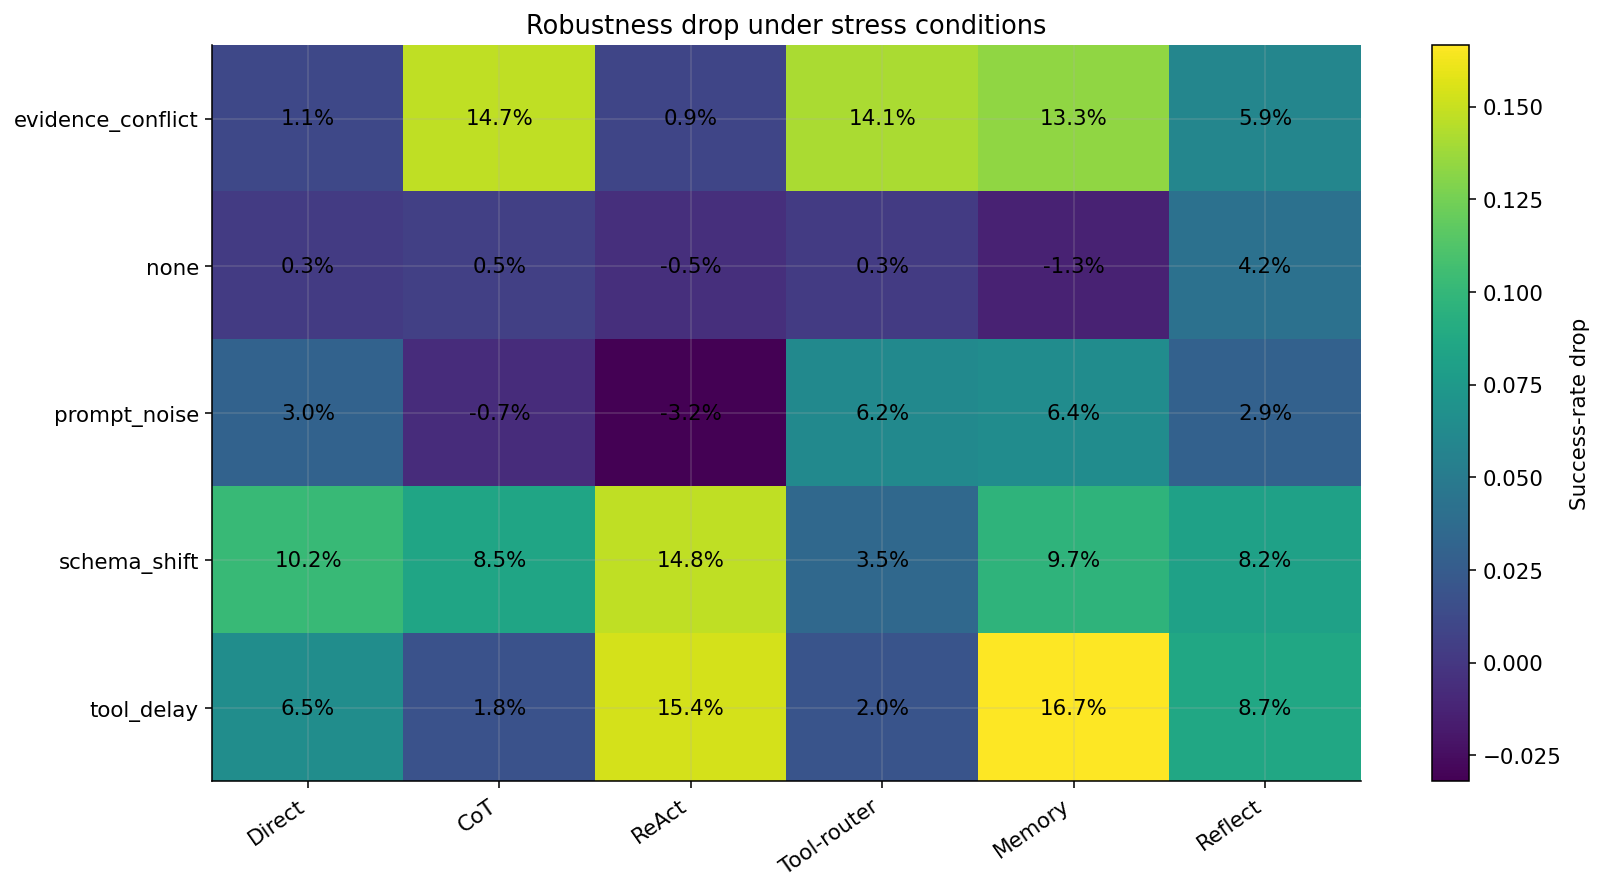

agent_short,Direct,CoT,ReAct,Tool-router,Memory,Reflect
stress_type,,,,,,
evidence_conflict,0.011364,0.147368,0.009434,0.141304,0.133333,0.059406
none,0.002755,0.005319,-0.005362,0.002591,-0.012723,0.042394
prompt_noise,0.030488,-0.007143,-0.032051,0.062069,0.064286,0.029412
schema_shift,0.101695,0.084746,0.147727,0.034783,0.097087,0.081633
tool_delay,0.065421,0.018018,0.153846,0.019608,0.166667,0.086538


In [11]:

# ============================================================
# 10. Robustness stress testing
# ============================================================

stress = (
    df.groupby(["agent_short", "stress_type"])
    .agg(success_rate=("success", "mean"), stressed_success_rate=("stressed_success", "mean"))
    .reset_index()
)
stress["drop"] = stress["success_rate"] - stress["stressed_success_rate"]

stress_pivot = stress.pivot(index="stress_type", columns="agent_short", values="drop")
stress_pivot = stress_pivot[["Direct","CoT","ReAct","Tool-router","Memory","Reflect"]]

fig, ax = plt.subplots(figsize=(12, 6.5))
im = ax.imshow(stress_pivot.values, aspect="auto")
ax.set_xticks(np.arange(len(stress_pivot.columns)))
ax.set_xticklabels(stress_pivot.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(len(stress_pivot.index)))
ax.set_yticklabels(stress_pivot.index)
ax.set_title("Robustness drop under stress conditions")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Success-rate drop")

for i in range(stress_pivot.shape[0]):
    for j in range(stress_pivot.shape[1]):
        ax.text(j, i, f"{stress_pivot.iloc[i, j]:.1%}", ha="center", va="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "07_robustness_drop_heatmap.png", bbox_inches="tight")
plt.show()

stress_pivot



## 4. Ablation analysis

A common research-engineering task is to identify which design choices are responsible for improved performance.

Here we compare:

- Direct prompting
- CoT-style prompting
- ReAct-style reasoning plus action
- Structured tool routing
- Memory
- Reflection and retry

The analysis is synthetic but demonstrates the workflow a research engineer might use after running actual experiments.


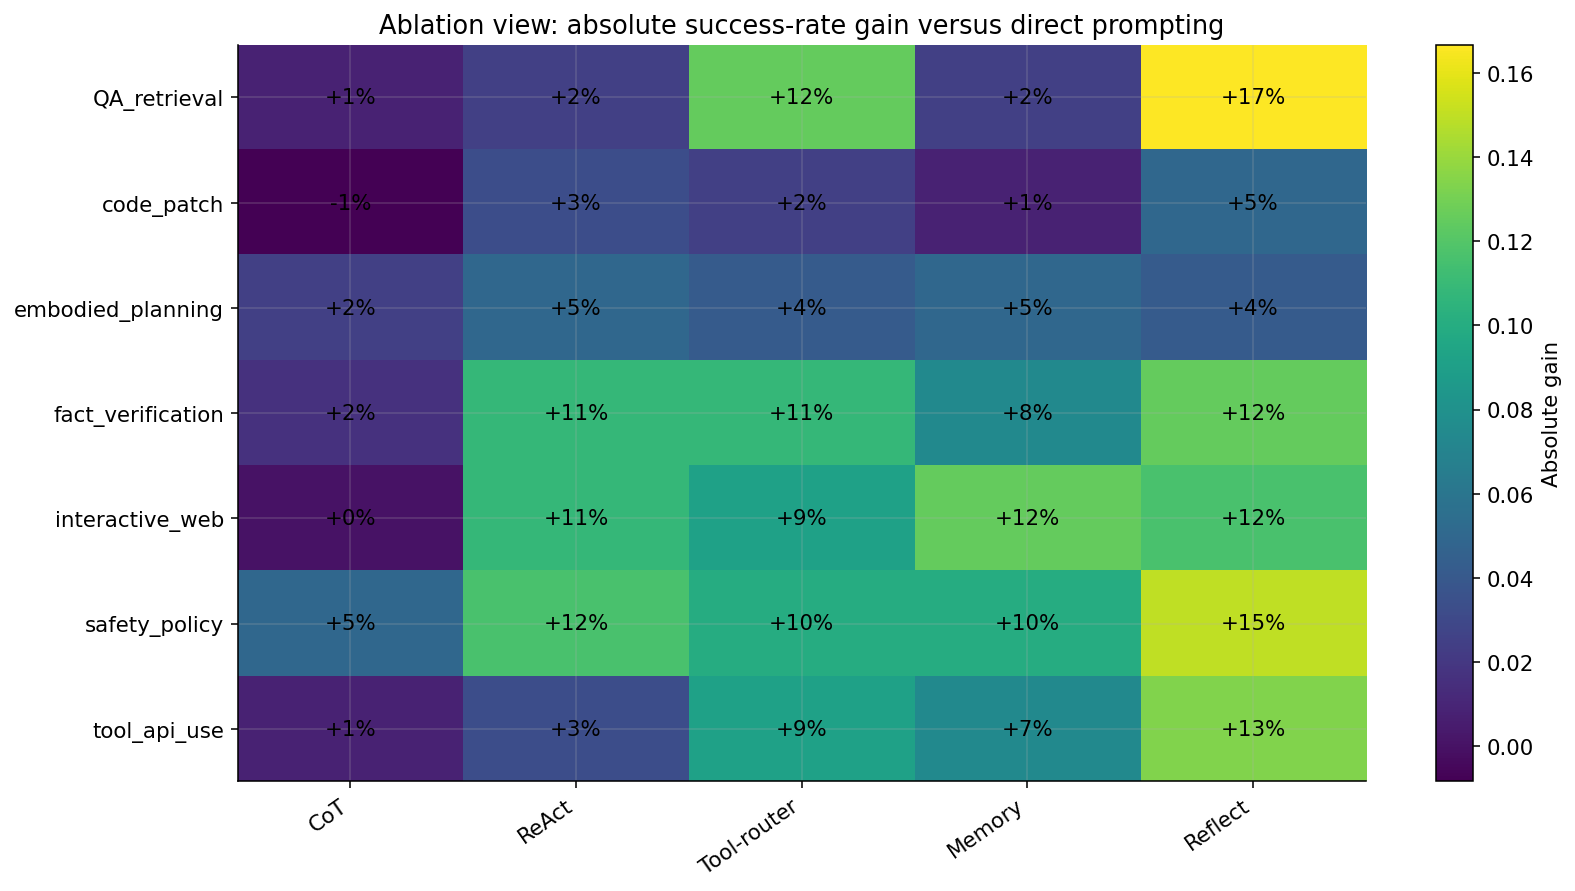

agent_short,CoT,ReAct,Tool-router,Memory,Reflect
task_family,,,,,
QA_retrieval,0.008333,0.025000,0.125000,0.025000,0.166667
code_patch,-0.008333,0.033333,0.025000,0.008333,0.050000
embodied_planning,0.025000,0.050000,0.041667,0.050000,0.041667
fact_verification,0.016667,0.108333,0.108333,0.075000,0.125000
interactive_web,0.000000,0.108333,0.091667,0.125000,0.116667
safety_policy,0.050000,0.116667,0.100000,0.100000,0.150000
tool_api_use,0.008333,0.033333,0.091667,0.075000,0.133333


In [12]:

# ============================================================
# 11. Ablation gains relative to Direct_LLM within each task family
# ============================================================

task_agent = (
    df.groupby(["task_family", "agent_short"])
    .agg(success_rate=("success", "mean"),
         hallucination_rate=("hallucination", "mean"),
         invalid_tool_rate=("invalid_tool_call", "mean"),
         latency=("latency_sec", "mean"),
         cost=("cost_units", "mean"))
    .reset_index()
)

base = task_agent[task_agent["agent_short"] == "Direct"][["task_family", "success_rate"]].rename(columns={"success_rate": "direct_success"})
task_agent = task_agent.merge(base, on="task_family")
task_agent["absolute_gain_vs_direct"] = task_agent["success_rate"] - task_agent["direct_success"]

gain_pivot = task_agent.pivot(index="task_family", columns="agent_short", values="absolute_gain_vs_direct")
gain_pivot = gain_pivot[["CoT","ReAct","Tool-router","Memory","Reflect"]]

fig, ax = plt.subplots(figsize=(12, 6.5))
im = ax.imshow(gain_pivot.values, aspect="auto")
ax.set_xticks(np.arange(len(gain_pivot.columns)))
ax.set_xticklabels(gain_pivot.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(len(gain_pivot.index)))
ax.set_yticklabels(gain_pivot.index)
ax.set_title("Ablation view: absolute success-rate gain versus direct prompting")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Absolute gain")

for i in range(gain_pivot.shape[0]):
    for j in range(gain_pivot.shape[1]):
        ax.text(j, i, f"{gain_pivot.iloc[i, j]:+.0%}", ha="center", va="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "08_ablation_gain_heatmap.png", bbox_inches="tight")
plt.show()

gain_pivot


In [13]:

# ============================================================
# 12. Statistical testing: Direct versus Reflect by task family
# ============================================================

test_rows = []
for task in df["task_family"].unique():
    direct = df[(df["task_family"] == task) & (df["agent_short"] == "Direct")]["success"].values
    reflect = df[(df["task_family"] == task) & (df["agent_short"] == "Reflect")]["success"].values

    table = np.array([
        [direct.sum(), len(direct) - direct.sum()],
        [reflect.sum(), len(reflect) - reflect.sum()],
    ])
    oddsratio, p = stats.fisher_exact(table)
    test_rows.append({
        "task_family": task,
        "direct_success": direct.mean(),
        "reflect_success": reflect.mean(),
        "absolute_gain": reflect.mean() - direct.mean(),
        "fisher_exact_p": p,
        "odds_ratio": oddsratio,
    })

tests = pd.DataFrame(test_rows).sort_values("absolute_gain", ascending=False)
tests.to_csv(DATA_DIR / "direct_vs_reflect_fisher_tests.csv", index=False)
tests


,task_family,direct_success,reflect_success,absolute_gain,fisher_exact_p,odds_ratio
0,QA_retrieval,0.258333,0.425000,0.166667,0.009502,0.471249
6,safety_policy,0.483333,0.633333,0.150000,0.026903,0.541596
4,tool_api_use,0.108333,0.241667,0.133333,0.010225,0.381244
1,fact_verification,0.308333,0.433333,0.125000,0.061071,0.582947
2,interactive_web,0.091667,0.208333,0.116667,0.017851,0.383486
5,code_patch,0.041667,0.091667,0.050000,0.194484,0.430830
3,embodied_planning,0.033333,0.075000,0.041667,0.253447,0.425287



## 5. Predictive modelling for failure triage

A research engineer often builds diagnostic tools to predict which jobs are likely to fail before spending GPU time or API budget.

Here we train a small logistic-regression model to predict task success from interpretable metadata. This is not meant to be a state-of-the-art model; it is a transparent engineering diagnostic.


In [14]:

# ============================================================
# 13. Failure triage model
# ============================================================

features = [
    "task_family",
    "agent_short",
    "task_complexity",
    "tool_need",
    "ambiguity",
    "context_length_k",
    "latency_sec",
    "total_tokens",
]
target = "success"

X = df[features].copy()
y = df[target].copy()

categorical = ["task_family", "agent_short"]
numeric = [c for c in features if c not in categorical]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric),
    ]
)

model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

model.fit(X_train, y_train)
pred_prob = model.predict_proba(X_test)[:, 1]
pred = (pred_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, pred_prob)
ap = average_precision_score(y_test, pred_prob)
brier = brier_score_loss(y_test, pred_prob)

print(f"Failure-triage model ROC-AUC: {auc:.3f}")
print(f"Average precision: {ap:.3f}")
print(f"Brier score: {brier:.3f}")
print()
print(classification_report(y_test, pred, digits=3))


Failure-triage model ROC-AUC: 0.760
Average precision: 0.469
Brier score: 0.198

              precision    recall  f1-score   support

           0      0.875     0.698     0.776       950
           1      0.428     0.694     0.530       310

    accuracy                          0.697      1260
   macro avg      0.651     0.696     0.653      1260
weighted avg      0.765     0.697     0.716      1260



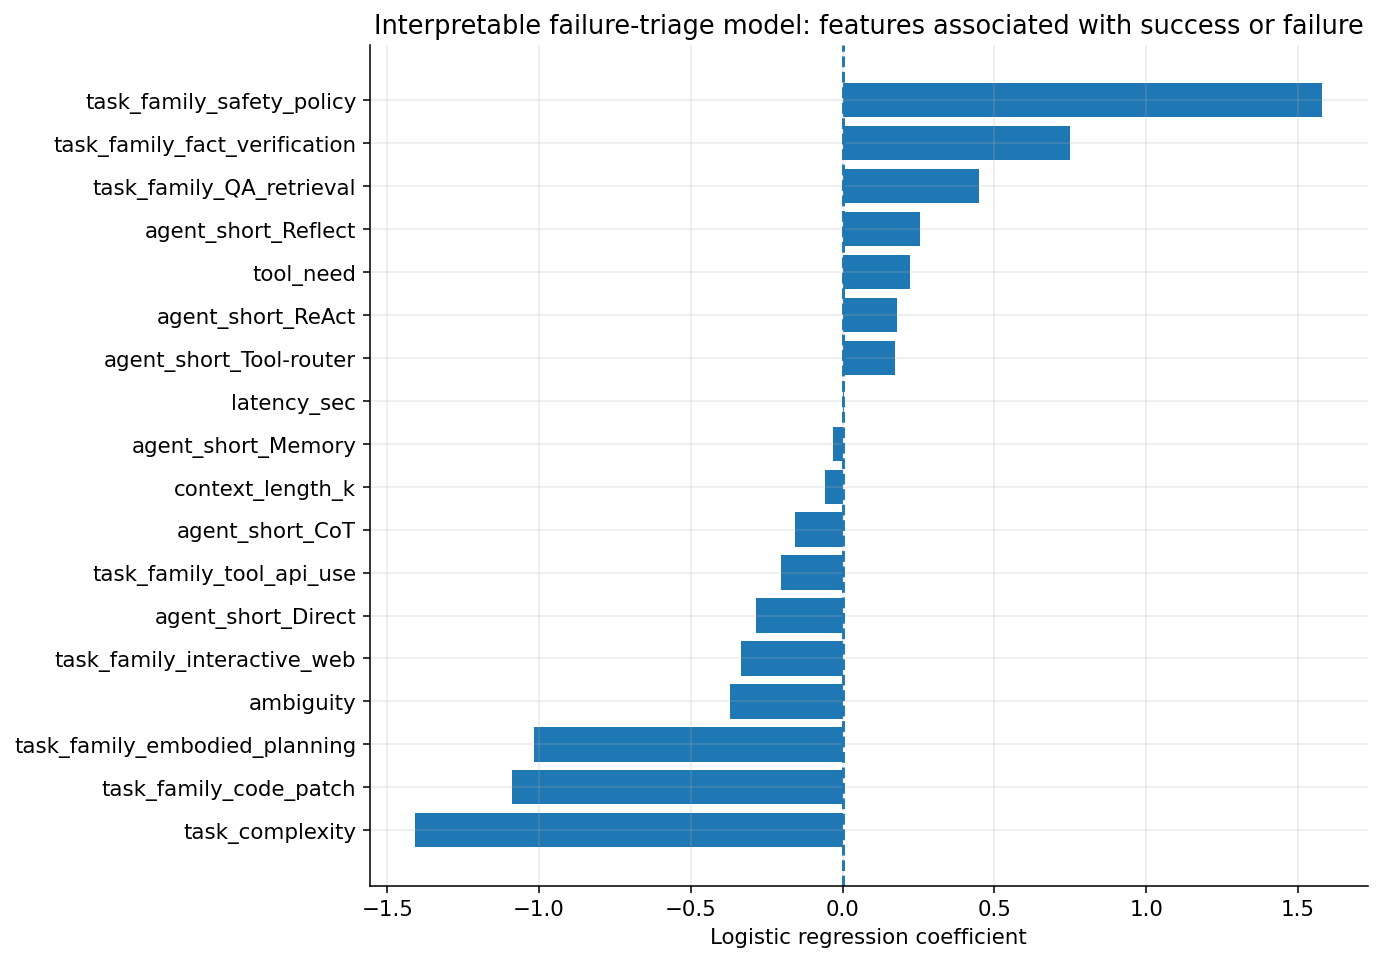

,feature,coefficient,abs_coefficient
5,task_family_safety_policy,1.580806,1.580806
13,task_complexity,-1.407942,1.407942
1,task_family_code_patch,-1.089673,1.089673
2,task_family_embodied_planning,-1.017412,1.017412
3,task_family_fact_verification,0.748362,0.748362
0,task_family_QA_retrieval,0.448677,0.448677
15,ambiguity,-0.372083,0.372083
4,task_family_interactive_web,-0.333767,0.333767
8,agent_short_Direct,-0.285094,0.285094
11,agent_short_Reflect,0.256007,0.256007


In [15]:

# ============================================================
# 14. Model coefficients for interpretability
# ============================================================

prep = model.named_steps["prep"]
clf = model.named_steps["clf"]

feature_names = list(prep.named_transformers_["cat"].get_feature_names_out(categorical)) + numeric
coef = pd.DataFrame({
    "feature": feature_names,
    "coefficient": clf.coef_[0],
})
coef["abs_coefficient"] = coef["coefficient"].abs()
coef = coef.sort_values("abs_coefficient", ascending=False).head(18)

fig, ax = plt.subplots(figsize=(10, 7))
coef_plot = coef.sort_values("coefficient")
ax.barh(coef_plot["feature"], coef_plot["coefficient"])
ax.axvline(0, linestyle="--")
ax.set_xlabel("Logistic regression coefficient")
ax.set_title("Interpretable failure-triage model: features associated with success or failure")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_failure_triage_coefficients.png", bbox_inches="tight")
plt.show()

coef


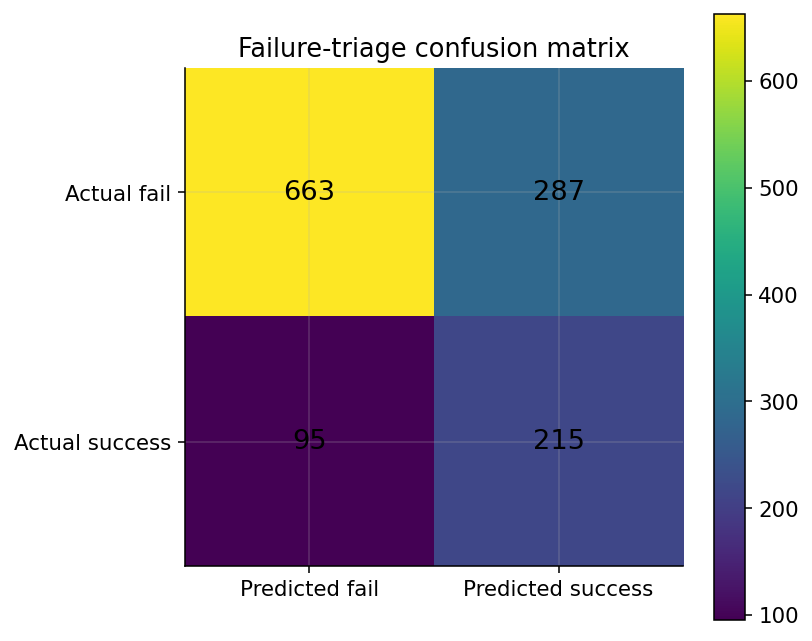

In [16]:

# ============================================================
# 15. Confusion matrix
# ============================================================

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)
ax.set_xticks([0,1])
ax.set_xticklabels(["Predicted fail", "Predicted success"])
ax.set_yticks([0,1])
ax.set_yticklabels(["Actual fail", "Actual success"])
ax.set_title("Failure-triage confusion matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha="center", va="center", fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_confusion_matrix.png", bbox_inches="tight")
plt.show()



## 6. Research-engineering deliverables

A strong Research Engineer does not only produce a plot. They produce reusable assets that other people can inspect, rerun, and extend.

This notebook saves:

- `data/synthetic_llm_agent_runs.csv`
- `data/agent_summary_metrics.csv`
- `data/bootstrap_success_ci.csv`
- `data/direct_vs_reflect_fisher_tests.csv`
- `figures/*.png`

The final section creates a concise report table and a markdown summary suitable for sharing with a research team.


In [17]:

# ============================================================
# 16. Generate shareable technical summary
# ============================================================

best_success = summary.sort_values("success_rate", ascending=False).iloc[0]
best_latency = summary.sort_values("mean_latency_sec", ascending=True).iloc[0]
best_calibration = summary.sort_values("ece", ascending=True).iloc[0]

report_lines = []
report_lines.append("# Synthetic LLM Agent Evaluation Report")
report_lines.append("")
report_lines.append("## Executive summary")
report_lines.append("")
report_lines.append(f"- Best overall success rate: **{best_success['agent_short']}** at **{best_success['success_rate']:.1%}**.")
report_lines.append(f"- Lowest mean latency: **{best_latency['agent_short']}** at **{best_latency['mean_latency_sec']:.1f} seconds**.")
report_lines.append(f"- Best calibration by ECE: **{best_calibration['agent_short']}** with **ECE={best_calibration['ece']:.3f}**.")
report_lines.append("")
report_lines.append("## Interpretation")
report_lines.append("")
report_lines.append(
    "Structured agents generally improved success on tool-heavy and long-horizon tasks, "
    "but they also increased latency and synthetic cost. This reproduces a common AI-systems "
    "engineering trade-off: more scaffolding improves reliability but consumes more compute and orchestration time."
)
report_lines.append("")
report_lines.append("## Recommended next experiments")
report_lines.append("")
report_lines.append("1. Add caching and tool-result reuse to reduce latency.")
report_lines.append("2. Add schema-aware retry logic for invalid tool calls.")
report_lines.append("3. Use automatic failure clustering to identify repeated prompt/tool bugs.")
report_lines.append("4. Add held-out adversarial tasks to improve robustness evaluation.")
report_lines.append("5. Add cost-aware routing, so simple tasks use cheap direct prompting and hard tasks use full agent scaffolding.")

report_md = "\n".join(report_lines)
(DATA_DIR / "synthetic_llm_agent_evaluation_report.md").write_text(report_md)

print(report_md)


# Synthetic LLM Agent Evaluation Report

## Executive summary

- Best overall success rate: **Reflect** at **30.1%**.
- Lowest mean latency: **Direct** at **31.1 seconds**.
- Best calibration by ECE: **ReAct** with **ECE=0.037**.

## Interpretation

Structured agents generally improved success on tool-heavy and long-horizon tasks, but they also increased latency and synthetic cost. This reproduces a common AI-systems engineering trade-off: more scaffolding improves reliability but consumes more compute and orchestration time.

## Recommended next experiments

1. Add caching and tool-result reuse to reduce latency.
2. Add schema-aware retry logic for invalid tool calls.
3. Use automatic failure clustering to identify repeated prompt/tool bugs.
4. Add held-out adversarial tasks to improve robustness evaluation.
5. Add cost-aware routing, so simple tasks use cheap direct prompting and hard tasks use full agent scaffolding.



## 7. How this demonstrates fit for a Research Engineer, AI Systems / LLM Agents role

This notebook demonstrates:

- **Python engineering:** reproducible dataset generation, metrics, modelling, and file outputs.
- **Agent evaluation:** direct, CoT-style, ReAct-style, tool-routing, memory, and reflection variants.
- **Research infrastructure mindset:** saved datasets, saved figures, reusable functions, and analysis outputs.
- **Scientific evaluation:** confidence intervals, statistical tests, calibration, robustness, and failure analysis.
- **Practical AI systems thinking:** trade-offs between success, latency, cost, hallucination, and tool reliability.
- **Communication:** clear visual summaries and an executive report.

## References

Bommasani, R., Liang, P., Lee, T., et al. (2023). Holistic Evaluation of Language Models. *Transactions on Machine Learning Research*. PubMed PMID: 37230490.

Yao, S., Zhao, J., Yu, D., et al. (2023). ReAct: Synergizing Reasoning and Acting in Language Models. *International Conference on Learning Representations*.

Qin, Y., Liang, S., Ye, Y., et al. (2024). ToolLLM: Facilitating Large Language Models to Master 16000+ Real-world APIs. *International Conference on Learning Representations*.

Guo, Z., et al. (2024). Towards Stable Large-Scale Benchmarking on Tool Learning of Large Language Models.

Jimenez, C. E., Yang, J., Wettig, A., et al. (2024). SWE-bench: Can Language Models Resolve Real-world GitHub Issues? *International Conference on Learning Representations*.
